In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

## Ex06
Сделай всё необходимое, чтобы получить график как на примере:
- Построй DataFrame, где для каждого пользователя из группы test есть: средняя дельта, число визитов в «Ленту», число коммитов.
- Не учитывай project1 при расчётах средней дельты и числа коммитов.
- Число коммитов возьми из таблицы checker.
- Размер фигуры — тот же; размер шрифта и палитру выбирай сам.
- Размер точек — 200.
- Толщина линий диагональных графиков (KDE) — 3.
- В конце блокнота добавь markdown-ячейку с вопросами (ответ — «да» или «нет»):
    - «Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, мало коммитов?»
    - «Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, малая средняя разница между первым коммитом и дедлайном лабораторной?»
    - «Можно ли сказать, что много пользователей с малым числом коммитов и немного — с большим числом коммитов?»
    - «Можно ли сказать, что много пользователей с малой средней разницей и немного — с большой средней разницей?»

In [2]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [3]:
avg_diff = pd.read_sql(
    """
    SELECT uid, CAST((unixepoch(first_commit_ts) - deadlines) / 3600 AS INTEGER) AS diff
    FROM test
    LEFT JOIN deadlines ON deadlines.labs = labname
    WHERE labname != 'project1'
    """,
    conn
)
avg_diff = avg_diff.groupby('uid')['diff'].mean().reset_index()
avg_diff.columns = ['uid', 'avg_diff']

avg_diff

,uid,avg_diff
0,user_1,-64.400000
1,user_10,-74.800000
2,user_14,-159.000000
3,user_17,-61.600000
4,user_18,-5.666667
5,user_19,-98.750000
6,user_21,-95.500000
7,user_25,-92.600000
8,user_28,-86.400000
9,user_3,-105.400000


In [4]:
num_commits = pd.read_sql(
    """
    SELECT uid, COUNT(*) AS num_commits
    FROM checker
    WHERE labname != 'project1'
        AND uid IN (SELECT DISTINCT uid FROM test)
    GROUP BY uid
    """,
    conn
)

num_commits.head(1)

,uid,num_commits
0,user_1,62


In [5]:
pageviews = pd.read_sql(
    """
    SELECT uid, COUNT(*) AS pageviews
    FROM pageviews
    WHERE uid IN (SELECT DISTINCT uid FROM test)
    GROUP BY uid
    """,
    conn
)

pageviews.head(1)

,uid,pageviews
0,user_1,28


In [6]:
df = avg_diff.merge(pageviews, on='uid').merge(num_commits, on='uid')
df = df.drop(columns='uid')
df

,avg_diff,pageviews,num_commits
0,-64.400000,28,62
1,-74.800000,89,20
2,-159.000000,143,61
3,-61.600000,47,51
4,-5.666667,3,5
5,-98.750000,16,118
6,-95.500000,10,65
7,-92.600000,179,79
8,-86.400000,149,60
9,-105.400000,317,18


array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

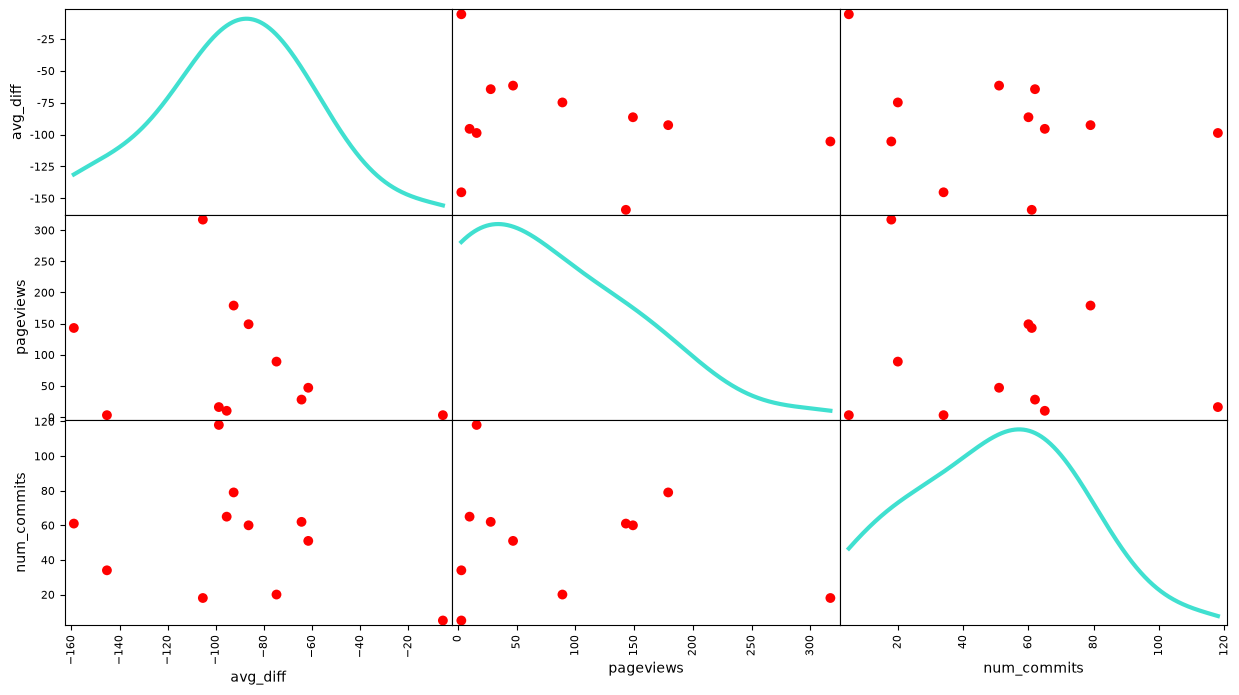

In [7]:
scatter_matrix(
    df,
    figsize=(15, 8),
    s=200,
    diagonal='kde',
    color='red',
    alpha=1.0,
    density_kwds=dict(linewidth=3, color='turquoise', alpha=1.0)
)

- «Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, мало коммитов?»
    - **нет**. по графику pageviews & num_commits видно, что на малых значениях просмотров коммиты варьируются от 0 до 120, поэтому взаимосвязи здесь нет
- «Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, малая средняя разница между первым коммитом и дедлайном лабораторной?»
    - **нет**. по графику pageviews & avg_diff на малых значениях просмотров наблюдается широкий разброс средней разницы между первым коммитом и дедлайном, связи нет
- «Можно ли сказать, что много пользователей с малым числом коммитов и немного — с большим числом коммитов?»
    - **да**. распределение num_commits скошено вправо, то есть площадь под кривой в диапазоне [0, 40] коммитов сильно больше площади под кривой в диапазоне [80, 120]
- «Можно ли сказать, что много пользователей с малой средней разницей и немного — с большой средней разницей?»
    - **нет**. распределение avg_diff чуть-чуть скошена вправо, малая средняя разница находится "в хвосте" распределения

In [8]:
conn.close()